In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel(r"C:\Users\aadhi\Downloads\laptop dataset.xlsx")
df

,Title,Brand,Screen_Size,CPU_Model,Ram,Operating_System,Rating,Series,Color,Resolution,Weight,USB,Battery,Graphics,Disk_size,Card_desc,Price
0,Microsoft Surface Laptop Intel Core i5 7th Gen...,Microsoft,13.5 Inches,1.2GHz Cortex A8 Processor,8 GB,Windows 10,4.4,Intel,Platinum,NaN,NaN,NaN,NaN,Intel HD Graphics 620,256 GB,Integrated,NaN
1,"Microsoft Surface Laptop 3 13.5"" Touch-Screen ...",Microsoft,13.5 Inches,Core i5,8 GB,Windows 10,4.4,Microsoft Surface,Matte Black,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Microsoft Surface Laptop (Intel Core i7, 16GB ...",Microsoft,13.5 Inches,Core i7,16 GB,Windows 10 S,3.9,Surface Laptop,Platinum,NaN,NaN,NaN,NaN,Intel Iris Plus Graphics 640,512 GB,Integrated,NaN
3,"Microsoft Surface Laptop 3, 10th Gen Intel Cor...",Microsoft,13 Inches,Core i5-1035G7,8 GB,Windows 10 Home,4.2,Surface Laptop 3,Cobalt Blue,NaN,NaN,NaN,NaN,Intel Iris Plus,NaN,Integrated,NaN
4,"2022 Microsoft Surface Laptop Go 12.4"" Touchsc...",Microsoft,12.4 Inches,Core i5,4 GB,Windows 11 Pro,3.9,Surface Laptop Go,Silver,NaN,NaN,NaN,NaN,NaN,256 GB,Integrated,$359.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,Platinum,NaN,NaN,NaN,NaN,Intel UHD Graphics,64 GB,Integrated,$262.99
2839,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,Platinum,NaN,NaN,NaN,NaN,Intel UHD Graphics,64 GB,Integrated,$262.99
2840,Microsoft Surface Laptop Go 12.4in Touchscreen...,Microsoft,12.4 Inches,Core i5-1035G1,8 GB,Windows 10,4.5,Surface Laptop Go,Ice Blue,NaN,NaN,NaN,NaN,Intel UHD Graphics,128 GB,Integrated,NaN
2841,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,Platinum,NaN,NaN,NaN,NaN,Intel UHD Graphics,64 GB,Integrated,$262.99


In [3]:
df['Price']=(
    df['Price'].str.replace('$','',regex=False)
)


In [4]:
df['Price']=(
    df['Price'].str.replace(',','',regex=False)
)

In [5]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean')

In [6]:
df[['Price']]=imputer.fit_transform(df[['Price']])

In [7]:
df['Price'].fillna(df['Price'].mean(),inplace=True)

C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\663709371.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price'].fillna(df['Price'].mean(),inplace=True)


In [8]:
df['Price'].iloc[1:10]

1    1031.521159
2    1031.521159
3    1031.521159
4     359.990000
5    1031.521159
6    2167.000000
7     818.000000
8     699.000000
9    2449.990000
Name: Price, dtype: float64

In [9]:
print(df[
      df['Card_desc'].str.contains("Window|ZenBook",case=False,na=False)
      ])

                                                  Title Brand Screen_Size  \
1879  ASUS Vivobook S 14 Flip 14â€ WUXGA 16:10 touc...  ASUS   14 Inches   
2178  ASUS ZenBook 14X OLED Laptop, 14â€ 2.8K 16:10...  ASUS          14   
2227  ASUS ZenBook 14X OLED Laptop, 14â€ 2.8K 16:10...  ASUS   14 Inches   
2234  ASUS VivoBook Flip 14 Thin and Light 2-in-1 La...  ASUS          14   
2447  ASUS ZenBook 14X OLED Space Edition Laptop, 14...  ASUS   14 Inches   

     CPU_Model    Ram Operating_System  Rating                   Series  \
1879   Ryzen 5   8 GB  Windows 11 Home     4.4  ASUS Vivobook 14 Laptop   
2178   Core i7  16 GB  Windows 11 Home     4.1         ASUS ZenBook 14X   
2227   Core i7  16 GB  Windows 11 Home     4.2         ASUS ZenBook 14X   
2234   Ryzen 7   8 GB  Windows 10 Home     4.4            TM420UA-DS71T   
2447   Core i9  32 GB   Windows 11 Pro     4.4         ASUS ZenBook 14X   

              Color Resolution Weight  USB Battery                Graphics  \
1879    

In [10]:
df=df[
      ~df['Card_desc'].str.contains("Window|ZenBook",case=False,na=False)
      ]


In [11]:
df=pd.get_dummies(df,columns=['Card_desc'])
dummies=pd.get_dummies(df)
print(dummies)

      Rating  USB        Price  Card_desc_AMD Radeon  \
0        4.4  NaN  1031.521159                 False   
1        4.4  NaN  1031.521159                 False   
2        3.9  NaN  1031.521159                 False   
3        4.2  NaN  1031.521159                 False   
4        3.9  NaN   359.990000                 False   
...      ...  ...          ...                   ...   
2838     4.2  NaN   262.990000                 False   
2839     4.2  NaN   262.990000                 False   
2840     4.5  NaN  1031.521159                 False   
2841     4.2  NaN   262.990000                 False   
2842     4.4  NaN   254.990000                 False   

      Card_desc_AMD Radeon Graphics  Card_desc_Dedicated  \
0                             False                False   
1                             False                False   
2                             False                False   
3                             False                False   
4                          

In [12]:
bool_cols=df.select_dtypes(bool).columns
df[bool_cols]=df[bool_cols].astype(int)

df

,Title,Brand,Screen_Size,CPU_Model,Ram,Operating_System,Rating,Series,Color,Resolution,...,Card_desc_RTX 3070 Ti,Card_desc_RTX 3080,Card_desc_RTX 3080 Ti,Card_desc_RTX 3080Ti,Card_desc_RTX A5000,Card_desc_RTX2050,Card_desc_RX 5500M,Card_desc_Radeon Vega 7,Card_desc_UHD Graphics,"Card_desc_UHD Graphics 500, Integrated"
0,Microsoft Surface Laptop Intel Core i5 7th Gen...,Microsoft,13.5 Inches,1.2GHz Cortex A8 Processor,8 GB,Windows 10,4.4,Intel,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0
1,"Microsoft Surface Laptop 3 13.5"" Touch-Screen ...",Microsoft,13.5 Inches,Core i5,8 GB,Windows 10,4.4,Microsoft Surface,Matte Black,NaN,...,0,0,0,0,0,0,0,0,0,0
2,"Microsoft Surface Laptop (Intel Core i7, 16GB ...",Microsoft,13.5 Inches,Core i7,16 GB,Windows 10 S,3.9,Surface Laptop,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0
3,"Microsoft Surface Laptop 3, 10th Gen Intel Cor...",Microsoft,13 Inches,Core i5-1035G7,8 GB,Windows 10 Home,4.2,Surface Laptop 3,Cobalt Blue,NaN,...,0,0,0,0,0,0,0,0,0,0
4,"2022 Microsoft Surface Laptop Go 12.4"" Touchsc...",Microsoft,12.4 Inches,Core i5,4 GB,Windows 11 Pro,3.9,Surface Laptop Go,Silver,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0
2839,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0
2840,Microsoft Surface Laptop Go 12.4in Touchscreen...,Microsoft,12.4 Inches,Core i5-1035G1,8 GB,Windows 10,4.5,Surface Laptop Go,Ice Blue,NaN,...,0,0,0,0,0,0,0,0,0,0
2841,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0


In [13]:
update_disk={
    '1 TB' : '1024 GB',
    '1.5 TB': '1536 GB',
    '2 TB' : '2048 GB',
    '3 TB' : '3072 GB',
    '4 TB' : '4096 GB',
    '1'   : '1024 GB',
    '2'  : '2048 GB'
}
df['Disk_size']=df['Disk_size'].replace(update_disk)

In [14]:
df['Disk_size']=df['Disk_size'].str.replace("GB|TB",'',regex=True)
df['Disk_size']=pd.to_numeric(df['Disk_size'])

In [15]:
imputer=SimpleImputer(strategy='constant',fill_value=500)

In [16]:
df[['Disk_size']]=imputer.fit_transform(df[['Disk_size']])

In [17]:
df['Disk_size'].iloc[2330:2350] 

2334     128.0
2335      64.0
2336     512.0
2337     512.0
2338      64.0
2339    1024.0
2340     256.0
2341    1024.0
2342    1024.0
2343    1024.0
2344      64.0
2345    1000.0
2346     512.0
2347    1024.0
2348     128.0
2349     500.0
2350     500.0
2351     512.0
2352      16.0
2353     500.0
Name: Disk_size, dtype: float64

In [18]:
df['Graphics']=df['Graphics'].str.replace('â€Ž|Â®|â„¢|áµ‰|ï¿½','',regex=True)


In [19]:
df['Graphics']=df['Graphics'].replace('600|1.06|2|4','nan')

In [20]:
df['Graphics']=df['Graphics'].fillna(df['Graphics'].mode()[0])

In [21]:
df['Graphics'].isnull().sum()

np.int64(0)

In [22]:
df=pd.get_dummies(df,columns=['Graphics'])

In [23]:
bool_cols=df.select_dtypes(bool).columns
df[bool_cols]=df[bool_cols].astype(int)

df

,Title,Brand,Screen_Size,CPU_Model,Ram,Operating_System,Rating,Series,Color,Resolution,...,Graphics_Radeon 560X,Graphics_Radeon Graphics,Graphics_Radeon RX 6800M Graphics,Graphics_Radeon RX Vega 8,Graphics_Radeon Vega 6 Graphics,Graphics_Shared,Graphics_UHD Graphics,Graphics_UHD Graphics 500,Graphics_UHD Graphics 600,Graphics_XPS9300-7909SLV-PUS
0,Microsoft Surface Laptop Intel Core i5 7th Gen...,Microsoft,13.5 Inches,1.2GHz Cortex A8 Processor,8 GB,Windows 10,4.4,Intel,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0
1,"Microsoft Surface Laptop 3 13.5"" Touch-Screen ...",Microsoft,13.5 Inches,Core i5,8 GB,Windows 10,4.4,Microsoft Surface,Matte Black,NaN,...,0,0,0,0,0,0,0,0,0,0
2,"Microsoft Surface Laptop (Intel Core i7, 16GB ...",Microsoft,13.5 Inches,Core i7,16 GB,Windows 10 S,3.9,Surface Laptop,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0
3,"Microsoft Surface Laptop 3, 10th Gen Intel Cor...",Microsoft,13 Inches,Core i5-1035G7,8 GB,Windows 10 Home,4.2,Surface Laptop 3,Cobalt Blue,NaN,...,0,0,0,0,0,0,0,0,0,0
4,"2022 Microsoft Surface Laptop Go 12.4"" Touchsc...",Microsoft,12.4 Inches,Core i5,4 GB,Windows 11 Pro,3.9,Surface Laptop Go,Silver,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0
2839,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0
2840,Microsoft Surface Laptop Go 12.4in Touchscreen...,Microsoft,12.4 Inches,Core i5-1035G1,8 GB,Windows 10,4.5,Surface Laptop Go,Ice Blue,NaN,...,0,0,0,0,0,0,0,0,0,0
2841,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,Platinum,NaN,...,0,0,0,0,0,0,0,0,0,0


In [24]:
df['Battery']=df['Battery'].str.replace('Hours','',regex=True)


In [25]:
df['Battery'].iloc[70:95]

70            NaN
71            NaN
72            NaN
73            18 
74            NaN
75            NaN
76            NaN
77            NaN
78            NaN
79            NaN
80            NaN
81            NaN
82            NaN
83            NaN
84            NaN
85            NaN
86            NaN
87    11.0, 17.0 
88            NaN
89            NaN
90            NaN
91            NaN
92            NaN
93            NaN
94            NaN
Name: Battery, dtype: object

In [26]:
df['Battery']=df['Battery'].str.split(',').str[0]
df['Battery']=pd.to_numeric(df['Battery'])

In [27]:
df['Battery'].iloc[305:315]

305     NaN
306     NaN
307     NaN
308    11.0
309     NaN
310     NaN
311     NaN
312     NaN
313     NaN
314     NaN
Name: Battery, dtype: float64

In [28]:
imputer=SimpleImputer(strategy='constant',fill_value=16)

In [29]:
df[['Battery']]=imputer.fit_transform(df[['Battery']])

In [30]:
imputer=SimpleImputer(strategy='mean')

In [31]:
df[['USB']]=imputer.fit_transform(df[['USB']])

In [32]:
 df['USB'].fillna(df['USB'].mean(),inplace=True)

C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\3556973594.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['USB'].fillna(df['USB'].mean(),inplace=True)


In [33]:
df['USB']=df['USB'].astype(int)

In [34]:
df['USB']

0       2
1       2
2       2
3       2
4       2
       ..
2838    2
2839    2
2840    2
2841    2
2842    2
Name: USB, Length: 2838, dtype: int64

In [35]:
update_weight={
    '1.8 Kilograms': '3.97 Pounds',
    '1043.26 Grams': '2.30 Pounds',
    '1.51 kilograms': '3.33 Pounds',
    '1.7 kilograms': '3.75 Pounds',
    '0.01 Ounces': '0.000625 Pounds'
}
df['Weight']=df['Weight'].replace(update_weight)
    

In [36]:
df['Weight'].iloc[689:710]

689    0.000625 Pounds
690                NaN
691                NaN
692                NaN
693                NaN
694                NaN
695                NaN
696                NaN
697                NaN
698                NaN
699                NaN
700                NaN
701                NaN
702       11.45 Pounds
703        2.30 Pounds
704                NaN
705                NaN
706                NaN
707                NaN
708                NaN
709                NaN
Name: Weight, dtype: object

In [37]:
df['Weight']=df['Weight'].str.replace('Ounces|Grams|Kilograms|Pounds','',regex=True)


In [38]:
df[['Weight']]=imputer.fit_transform(df[['Weight']])

In [39]:
df['Weight'].fillna(df['Weight'].mean(),inplace=True)

C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\371550695.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight'].fillna(df['Weight'].mean(),inplace=True)


In [40]:
df['Weight']

0       4.906998
1       4.906998
2       4.906998
3       4.906998
4       4.906998
          ...   
2838    4.906998
2839    4.906998
2840    4.906998
2841    4.906998
2842    4.906998
Name: Weight, Length: 2838, dtype: float64

In [41]:
df['Resolution']=df['Resolution'].str.split(',').str[0]
df['Resolution'].iloc[70:100]

70      NaN
71      NaN
72       4K
73      NaN
74    1080p
75      NaN
76      NaN
77    1080p
78      NaN
79    1080p
80       8K
81      NaN
82      NaN
83      NaN
84    1080p
85      NaN
86      NaN
87    1080p
88      NaN
89      NaN
90      NaN
91      NaN
92      NaN
93      NaN
94      NaN
95      NaN
96      NaN
97      NaN
98      NaN
99      NaN
Name: Resolution, dtype: object

In [42]:
resolution_map = {
    '720p': '1280x720',
    '1080p': '1920x1080',
    'FHD 1080p': '1920x1080',
    '2K': '2048x1080',
    '4K': '3840x2160',
    '8K': '7680x4320',
    '10K': '10240x4320',
    'XGA': '1024x768',
    'Retina':'2560x1600'
}

# Replace names with actual resolutions
df['Resolution'] = df['Resolution'].replace(resolution_map)

# Split into Width and Height
df[['Width','Height']] = df['Resolution'].str.split('x', expand=True)

# Convert to numeric
df['Width'] = pd.to_numeric(df['Width'], errors='coerce')
df['Height'] = pd.to_numeric(df['Height'], errors='coerce')

C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\2467711956.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Width','Height']] = df['Resolution'].str.split('x', expand=True)
C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\2467711956.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['Width','Height']] = df['Resolution'].str.split('x', expand=True)


In [43]:
df['Width'].fillna(df['Width'].median(),inplace=True)
df['Height'].fillna(df['Height'].median(),inplace=True)

C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\2346752262.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Width'].fillna(df['Width'].median(),inplace=True)
C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\2346752262.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [44]:
df['Resolution'].iloc[100:150]

100    2560x1600
101          NaN
102          NaN
103    3840x2160
104    7680x4320
105          NaN
106          NaN
107          NaN
108          NaN
109          NaN
110          NaN
111    2560x1600
112          NaN
113          NaN
114    3840x2160
115    7680x4320
116          NaN
117          NaN
118          NaN
119          NaN
120          NaN
121          NaN
122          NaN
123          NaN
124          NaN
125          NaN
126          NaN
127          NaN
128          NaN
129          NaN
130    7680x4320
131          NaN
132          NaN
133          NaN
134          NaN
135          NaN
136          NaN
137          NaN
138          NaN
139          NaN
140          NaN
141          NaN
142          NaN
143          NaN
144          NaN
145          NaN
146          NaN
147          NaN
148          NaN
149          NaN
Name: Resolution, dtype: object

In [45]:
df.drop('Resolution',axis=1,inplace=True)

In [46]:
df=df[
      ~df['Color'].str.contains('13" 1.7GHz / 8GB Memory / 256GB Solid State Drive|I9-12900H|Y13|Windows|15.6" | AERO 15 OLED | 2019|Console|2022|NON-TOUCH|I5-11400H - RTX 3050 Ti - 16GB | 512GB|R7 5800HS-RTX 3060-40GB|1TB|8GB LPDDR4X RAM | 64GB eMMC+32G SD CARD|Intel UHD Graphics|S13 A|RX 6700S|256GB SSD|RAM',case=False,na=False)]

In [47]:
print(df[
      df['Color'].str.contains('13" 1.7GHz / 8GB Memory / 256GB Solid State Drive|I9-12900H|Y13|Windows|15.6" | AERO 15 OLED | 2019|Console|2022|NON-TOUCH|I5-11400H - RTX 3050 Ti - 16GB | 512GB|R7 5800HS-RTX 3060-40GB|1TB|8GB LPDDR4X RAM | 64GB eMMC+32G SD CARD|Intel UHD Graphics|S13 A|RX 6700S|256GB SSD|RAm',case=False,na=False)])

Empty DataFrame
Columns: [Title, Brand, Screen_Size, CPU_Model, Ram, Operating_System, Rating, Series, Color, Weight, USB, Battery, Disk_size, Price, Card_desc_AMD Radeon, Card_desc_AMD Radeon Graphics, Card_desc_Dedicated, Card_desc_GeForce MX350, Card_desc_GeForce MX450, Card_desc_GeForce RTX 3050, Card_desc_GeForce RTX 3050 Ti, Card_desc_GeForce RTX 3070, Card_desc_Integrated, Card_desc_Integrated - 2020 Version, Card_desc_Integrated AMD Radeonâ„¢ Graphics, Card_desc_Integrated Touchscreen, Card_desc_Integrated, Dedicated, Card_desc_Intel HD Graphics 520, Integrated, Card_desc_Intel HD Graphics 6000, Integrated, Card_desc_Intel HD Graphics 620, Integrated, Card_desc_Intel Integrated Graphics, Integrated, Card_desc_Intel Iris Plus Graphics, Card_desc_Intel Iris Xe, Card_desc_Intel Iris Xe Graphics, Card_desc_Intel Iris Xáµ‰, Card_desc_Intel Iris, Integrated, Card_desc_Intel UHD Graphics, Card_desc_Intel UHD Graphics 620, Integrated, Card_desc_Intel UHD Graphics with shared graphics m

In [48]:
df['Color']=df['Color'].str.replace('â€Ž|Â','',regex=True)

C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\4001000905.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Color']=df['Color'].str.replace('â€Ž|Â','',regex=True)


In [49]:
df['Color'].iloc[117:135]

152       Core Black
153             Blue
154              NaN
156      Carbon Gray
157            Black
158              NaN
159    Titanium Blue
160       Blue Stone
161            Black
162       Core Black
163      Carbon Gray
164      Carbon Gray
165              NaN
166              NaN
167       Core Black
168        Ink Black
169             Gray
171            Black
Name: Color, dtype: object

In [50]:
df['Color']=df['Color'].fillna(df['Color'].mode()[0])

C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\664909463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Color']=df['Color'].fillna(df['Color'].mode()[0])


In [51]:
df['Color'].isnull().sum()

np.int64(0)

In [52]:
df=pd.get_dummies(df,columns=['Color'])


In [53]:
df

,Title,Brand,Screen_Size,CPU_Model,Ram,Operating_System,Rating,Series,Weight,USB,...,Color_Stealth Silver,Color_Storm Grey,Color_Tech Black,Color_Titan Gray,Color_Titanium Blue,Color_Titanium Gray,Color_Transparent Silver,Color_Underwater Teal,Color_Urban Silver,Color_White
0,Microsoft Surface Laptop Intel Core i5 7th Gen...,Microsoft,13.5 Inches,1.2GHz Cortex A8 Processor,8 GB,Windows 10,4.4,Intel,4.906998,2,...,False,False,False,False,False,False,False,False,False,False
1,"Microsoft Surface Laptop 3 13.5"" Touch-Screen ...",Microsoft,13.5 Inches,Core i5,8 GB,Windows 10,4.4,Microsoft Surface,4.906998,2,...,False,False,False,False,False,False,False,False,False,False
2,"Microsoft Surface Laptop (Intel Core i7, 16GB ...",Microsoft,13.5 Inches,Core i7,16 GB,Windows 10 S,3.9,Surface Laptop,4.906998,2,...,False,False,False,False,False,False,False,False,False,False
3,"Microsoft Surface Laptop 3, 10th Gen Intel Cor...",Microsoft,13 Inches,Core i5-1035G7,8 GB,Windows 10 Home,4.2,Surface Laptop 3,4.906998,2,...,False,False,False,False,False,False,False,False,False,False
4,"2022 Microsoft Surface Laptop Go 12.4"" Touchsc...",Microsoft,12.4 Inches,Core i5,4 GB,Windows 11 Pro,3.9,Surface Laptop Go,4.906998,2,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,4.906998,2,...,False,False,False,False,False,False,False,False,False,False
2839,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,4.906998,2,...,False,False,False,False,False,False,False,False,False,False
2840,Microsoft Surface Laptop Go 12.4in Touchscreen...,Microsoft,12.4 Inches,Core i5-1035G1,8 GB,Windows 10,4.5,Surface Laptop Go,4.906998,2,...,False,False,False,False,False,False,False,False,False,False
2841,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,Windows 10 Pro,4.2,Surface Go,4.906998,2,...,False,False,False,False,False,False,False,False,False,False


In [54]:
imputer=SimpleImputer(strategy='constant',fill_value=4.0)
df[['Rating']]=imputer.fit_transform(df[['Rating']])

In [55]:
df['Rating'].iloc[1:20]

1     4.4
2     3.9
3     4.2
4     3.9
5     4.3
6     4.4
7     4.3
8     4.5
9     5.0
10    5.0
19    4.1
20    3.1
21    5.0
23    4.0
28    5.0
32    4.2
33    4.8
34    4.7
35    3.9
Name: Rating, dtype: float64

In [56]:
df['Rating'].isnull().sum()

np.int64(0)

In [57]:
df['Operating_System']=df['Operating_System'].fillna(df['Operating_System'].mode()[0])

In [58]:
df['Operating_System'].isnull().sum()

np.int64(0)

In [59]:
df=pd.get_dummies(df,columns=['Operating_System'])

In [60]:
df

,Title,Brand,Screen_Size,CPU_Model,Ram,Rating,Series,Weight,USB,Battery,...,Operating_System_Windows 8 Professional,Operating_System_Windows 8.1,Operating_System_Windows XP Professional,Operating_System_Windows XP Professional 32 bit,Operating_System_Windows vista,Operating_System_Windows xp,"Operating_System_Windows, Windows 11",Operating_System_Windows_xp,Operating_System_Windwos 11,Operating_System_macOS 10.14 Mojave
0,Microsoft Surface Laptop Intel Core i5 7th Gen...,Microsoft,13.5 Inches,1.2GHz Cortex A8 Processor,8 GB,4.4,Intel,4.906998,2,16.0,...,False,False,False,False,False,False,False,False,False,False
1,"Microsoft Surface Laptop 3 13.5"" Touch-Screen ...",Microsoft,13.5 Inches,Core i5,8 GB,4.4,Microsoft Surface,4.906998,2,16.0,...,False,False,False,False,False,False,False,False,False,False
2,"Microsoft Surface Laptop (Intel Core i7, 16GB ...",Microsoft,13.5 Inches,Core i7,16 GB,3.9,Surface Laptop,4.906998,2,16.0,...,False,False,False,False,False,False,False,False,False,False
3,"Microsoft Surface Laptop 3, 10th Gen Intel Cor...",Microsoft,13 Inches,Core i5-1035G7,8 GB,4.2,Surface Laptop 3,4.906998,2,16.0,...,False,False,False,False,False,False,False,False,False,False
4,"2022 Microsoft Surface Laptop Go 12.4"" Touchsc...",Microsoft,12.4 Inches,Core i5,4 GB,3.9,Surface Laptop Go,4.906998,2,16.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,4.2,Surface Go,4.906998,2,16.0,...,False,False,False,False,False,False,False,False,False,False
2839,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,4.2,Surface Go,4.906998,2,16.0,...,False,False,False,False,False,False,False,False,False,False
2840,Microsoft Surface Laptop Go 12.4in Touchscreen...,Microsoft,12.4 Inches,Core i5-1035G1,8 GB,4.5,Surface Laptop Go,4.906998,2,16.0,...,False,False,False,False,False,False,False,False,False,False
2841,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",Microsoft,12.4 Inches,Core i5-1035G1,4 GB,4.2,Surface Go,4.906998,2,16.0,...,False,False,False,False,False,False,False,False,False,False


In [61]:
update_ram={
    '16 MB' : '0.0156 GB'
}
df['Ram']=df['Ram'].replace(update_ram)

In [62]:
df=df[~df['Ram'].astype(str).str.contains('TB', case=True)]

In [63]:
df=df.copy()

In [64]:
df['Ram']=df['Ram'].str.replace('GB','',regex=False)
df['Ram']=pd.to_numeric(df['Ram'])

In [65]:
imputer=SimpleImputer(strategy='constant',fill_value=10)
df[['Ram']]=imputer.fit_transform(df[['Ram']])

In [66]:
df['Ram'].isnull().sum()

np.int64(0)

In [67]:
update_Screen={
    '1 Centimeters': '0.3937 Inches'
}
df['Screen_Size']=df['Screen_Size'].replace(update_Screen)


In [68]:
df['Screen_Size'].iloc[1330:1340]

1449      15.6 Inches
1450      15.6 Inches
1451    0.3937 Inches
1452              NaN
1453    0.3937 Inches
1454              NaN
1456      17.3 Inches
1457              NaN
1458      17.3 Inches
1459      15.6 Inches
Name: Screen_Size, dtype: object

In [69]:
df['Screen_Size']=df['Screen_Size'].str.replace('Inches|centimeters','',regex=True)
df['Screen_Size']=pd.to_numeric(df['Screen_Size'])

In [70]:
imputer=SimpleImputer(strategy='constant',fill_value=11.4)
df[['Screen_Size']]=imputer.fit_transform(df[['Screen_Size']])

In [71]:
df['Screen_Size'].isnull().sum()

np.int64(0)

In [72]:
df['Brand']=df['Brand'].fillna(df['Brand'].mode()[0])
df['Brand'].isnull().sum()

np.int64(0)

In [73]:
df=df[
      ~df["Brand"].str.contains('Toughbook|WAKST|Unknown',case=False,na=False)]


In [74]:
print(df[
      df["Brand"].str.contains('Toughbook|WAKST|Unknown',case=False,na=False)])


Empty DataFrame
Columns: [Title, Brand, Screen_Size, CPU_Model, Ram, Rating, Series, Weight, USB, Battery, Disk_size, Price, Card_desc_AMD Radeon, Card_desc_AMD Radeon Graphics, Card_desc_Dedicated, Card_desc_GeForce MX350, Card_desc_GeForce MX450, Card_desc_GeForce RTX 3050, Card_desc_GeForce RTX 3050 Ti, Card_desc_GeForce RTX 3070, Card_desc_Integrated, Card_desc_Integrated - 2020 Version, Card_desc_Integrated AMD Radeonâ„¢ Graphics, Card_desc_Integrated Touchscreen, Card_desc_Integrated, Dedicated, Card_desc_Intel HD Graphics 520, Integrated, Card_desc_Intel HD Graphics 6000, Integrated, Card_desc_Intel HD Graphics 620, Integrated, Card_desc_Intel Integrated Graphics, Integrated, Card_desc_Intel Iris Plus Graphics, Card_desc_Intel Iris Xe, Card_desc_Intel Iris Xe Graphics, Card_desc_Intel Iris Xáµ‰, Card_desc_Intel Iris, Integrated, Card_desc_Intel UHD Graphics, Card_desc_Intel UHD Graphics 620, Integrated, Card_desc_Intel UHD Graphics with shared graphics memory, Card_desc_Intel XE

In [75]:
df=pd.get_dummies(df,columns=['Brand'])

In [76]:
df

,Title,Screen_Size,CPU_Model,Ram,Rating,Series,Weight,USB,Battery,Disk_size,...,Brand_Panasonic,Brand_REPOWER REPAIR REFURBISH REUSE,Brand_Razer,Brand_SAMSUNG,Brand_Sceptre,Brand_SewSwank,Brand_TECLAST,Brand_Thomson,Brand_Tomtoc,Brand_VGKE
0,Microsoft Surface Laptop Intel Core i5 7th Gen...,13.5,1.2GHz Cortex A8 Processor,8.0,4.4,Intel,4.906998,2,16.0,256.0,...,False,False,False,False,False,False,False,False,False,False
1,"Microsoft Surface Laptop 3 13.5"" Touch-Screen ...",13.5,Core i5,8.0,4.4,Microsoft Surface,4.906998,2,16.0,500.0,...,False,False,False,False,False,False,False,False,False,False
2,"Microsoft Surface Laptop (Intel Core i7, 16GB ...",13.5,Core i7,16.0,3.9,Surface Laptop,4.906998,2,16.0,512.0,...,False,False,False,False,False,False,False,False,False,False
3,"Microsoft Surface Laptop 3, 10th Gen Intel Cor...",13.0,Core i5-1035G7,8.0,4.2,Surface Laptop 3,4.906998,2,16.0,500.0,...,False,False,False,False,False,False,False,False,False,False
4,"2022 Microsoft Surface Laptop Go 12.4"" Touchsc...",12.4,Core i5,4.0,3.9,Surface Laptop Go,4.906998,2,16.0,256.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",12.4,Core i5-1035G1,4.0,4.2,Surface Go,4.906998,2,16.0,64.0,...,False,False,False,False,False,False,False,False,False,False
2839,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",12.4,Core i5-1035G1,4.0,4.2,Surface Go,4.906998,2,16.0,64.0,...,False,False,False,False,False,False,False,False,False,False
2840,Microsoft Surface Laptop Go 12.4in Touchscreen...,12.4,Core i5-1035G1,8.0,4.5,Surface Laptop Go,4.906998,2,16.0,128.0,...,False,False,False,False,False,False,False,False,False,False
2841,"Microsoft Surface Laptop Go 12.4"" Touchscreen ...",12.4,Core i5-1035G1,4.0,4.2,Surface Go,4.906998,2,16.0,64.0,...,False,False,False,False,False,False,False,False,False,False


In [77]:
df['Title']=df['Title'].str.replace(r'[^a-zA-z0-9\s.,/-]','',regex=True)

In [78]:
df['Title'].iloc[300:320]

375    Apple MacBook Pro MC975LL/A 15.4-Inch Laptop w...
388    MSI Titan GT77 17.3 UHD 120Hz Gaming Laptop In...
389    MSI Titan GT77 17.3 UHD 144Hz Mini LED Intel C...
390    MSI Modern 14 14 Ultra Thin and Light Professi...
391    MSI Modern 15 15.6 Ultra Thin and Light Laptop...
392    MSI Modern 15A Thin and Light Daily Laptop 15....
393    MSI Rainbow 6 Special EdiTion Crosshair15 15.6...
394    MSI GF75 Thin Gaming Laptop, 17.3 FHD 120Hz IP...
395    MSI GS76 Stealth Gaming Laptop 17.3 300Hz FHD ...
396    MSI Summit E16 FLIP EVO 16 QHD Touch Ultra Thi...
397    MSI Creator 15 Professional Laptop 15.6 UHD OL...
398    MSI GF63 15.6 144hz Gaming Laptop Intel Core i...
399    MSI Summit E16 FLIP 16 QHD Touch Ultra Thin 2-...
400    MSI Newest GF63 Thin 15.6 FHD Gaming Laptop, 1...
409    Apple 2020 MacBook Air Laptop M1 Chip, 13 Reti...
410    HP Chromebook Laptop Student Business 2022 Mod...
411    2021 Newest HP 14 inch HD Laptop Computer, Int...
412    2021 HP Stream 14 HD Lap

In [79]:
df=pd.get_dummies(df,columns=['Title'])

In [80]:
df

,Screen_Size,CPU_Model,Ram,Rating,Series,Weight,USB,Battery,Disk_size,Price,...,"Title_Windows 11 Laptop, BiTECOOL 14 inches FHD1920 x 1080 IPS Display, Intel Celeron N5095 Quad Core, 12GB RAM and 256GB NVMe SSD Laptop Computer, 2.4G/5G WiFi, BT4.2 and Camera Cover Slide, Brushed Grey","Title_[512GB M.2 SSD Version] GPD MicroPC Micro PC 6-inch Handheld Industry Laptop Mini PC Computer Win 10 Pro Supports RS-232,RJ45,Type C,USB 3.0,8GB RAM","Title_[Windows 11 Home] Newest HP 17 Laptop, 17.3 HD Screen, AMD Athlon Gold 3150U Processor, 8GB DDR4 RAM, 1TB PCIe SSD, Wi-Fi, Webcam, Zoom Meeting, HDMI, Black","Title_[Windows 11 Pro] HP 15 15.6 FHD Business Laptop Computer, 11th Generation Intel 4-core i5-1135G7 Beat i7-1160G7, 32GB RAM 1TB PCIe SSD, Intel Iris Xe Graphics, Numeric Keypad, BT 5.2, HDMI, w/Hub","Title_[Windows 11] Alienware m15 R5 GeForce RTX 3070 8GB GDDR6 15.6 360Hz FHD Gaming Laptop, Octa-Core AMD Ryzen 9 5900HX Beat i9-11980HK, 16GB DDR4 RAM, 2TB PCIe SSD, WiFi 6, Bluetooth 5.2, RGB Keyboard","Title_asus Chromebook 14 FHD Touchscreen 2 in 1 Thin, Light Laptop, Intel Core M3-8100Y Up to 3.4GHz, 8GB RAM, 128GB Storage64GB eMMC64GB Micro SD, Wi-Fi 6, Webcam, Zoom Meeting, Chrome OS, Silver",Title_bto Tb 19 I5-3320m 2.60g 4gb 500gb 10.1in-xga Wl Tpm Bt W7p,"Title_eHP 15-inch FHD Touchscreen IPS Display Laptop, AMD Ryzen 5 5500U, 8 GB RAM, 256 GB SSD, Windows 11 Home, Natural Silver","Title_jumper Laptop 14 Inch Full HD 1080P Display,12GB RAM,256GB SSD,Intel Celeron 64-bit,Windows 11 Laptops Computerwith WiFi,USB3.0,Bluetooth 4.2,Mini HDMI Gray","Title_tomtoc 360 Protective Laptop Sleeve for 13.5-14.4 Inch New Microsoft Surface Laptop Studio/5/4/3/2/1, Surface Book 3/2/1, Waterproof Accessories Carrying Case Bag for Asus ZenBook/ VivoBook 14, Black"
0,13.5,1.2GHz Cortex A8 Processor,8.0,4.4,Intel,4.906998,2,16.0,256.0,1031.521159,...,False,False,False,False,False,False,False,False,False,False
1,13.5,Core i5,8.0,4.4,Microsoft Surface,4.906998,2,16.0,500.0,1031.521159,...,False,False,False,False,False,False,False,False,False,False
2,13.5,Core i7,16.0,3.9,Surface Laptop,4.906998,2,16.0,512.0,1031.521159,...,False,False,False,False,False,False,False,False,False,False
3,13.0,Core i5-1035G7,8.0,4.2,Surface Laptop 3,4.906998,2,16.0,500.0,1031.521159,...,False,False,False,False,False,False,False,False,False,False
4,12.4,Core i5,4.0,3.9,Surface Laptop Go,4.906998,2,16.0,256.0,359.990000,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,12.4,Core i5-1035G1,4.0,4.2,Surface Go,4.906998,2,16.0,64.0,262.990000,...,False,False,False,False,False,False,False,False,False,False
2839,12.4,Core i5-1035G1,4.0,4.2,Surface Go,4.906998,2,16.0,64.0,262.990000,...,False,False,False,False,False,False,False,False,False,False
2840,12.4,Core i5-1035G1,8.0,4.5,Surface Laptop Go,4.906998,2,16.0,128.0,1031.521159,...,False,False,False,False,False,False,False,False,False,False
2841,12.4,Core i5-1035G1,4.0,4.2,Surface Go,4.906998,2,16.0,64.0,262.990000,...,False,False,False,False,False,False,False,False,False,False


In [81]:
if df['CPU_Model'].str.contains(r'[^a-zA-z0-9\s.,/-]','',regex=True,na=False).any():
    print("Yes")
else:
    print("No")

No


In [82]:
df=df[
      ~df['CPU_Model'].str.contains("Unknown",case=False,na=False)
      ]


In [83]:
if df['CPU_Model'].str.contains('Unknown','',regex=True,na=False).any():
    print("Yes")
else:
    print("No")

No


In [84]:
df['CPU_Model'].iloc[2440:2460]

2748           Core i5
2749    Core i5-10210Y
2750               NaN
2751               NaN
2752               NaN
2753           Core i7
2754               NaN
2755               NaN
2757               NaN
2758           Core i7
2759     Core M Family
2760               NaN
2761           Core i5
2763    Core i5-1035G4
2764           Ryzen 7
2765     Celeron N4000
2767               NaN
2768           Core i7
2769     Core i5 8400T
2770           Core i5
Name: CPU_Model, dtype: object

In [85]:
df['CPU_Model']=df['CPU_Model'].str.replace('8032|68040','nan',regex=True)

C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\2265773063.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CPU_Model']=df['CPU_Model'].str.replace('8032|68040','nan',regex=True)


In [86]:
df['CPU_Model'].isnull().sum()

np.int64(233)

In [87]:
df['CPU_Model']=df['CPU_Model'].fillna(df['CPU_Model'].mode()[0])
df['CPU_Model'].isnull().sum()

C:\Users\aadhi\AppData\Local\Temp\ipykernel_2584\1562083586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CPU_Model']=df['CPU_Model'].fillna(df['CPU_Model'].mode()[0])


np.int64(0)

In [88]:
df=pd.get_dummies(df,columns=['CPU_Model'])

In [89]:
df

,Screen_Size,Ram,Rating,Series,Weight,USB,Battery,Disk_size,Price,Card_desc_AMD Radeon,...,CPU_Model_Ryzen 7 4700U,CPU_Model_Ryzen 7 4800H,CPU_Model_Ryzen 7 5700U,CPU_Model_Ryzen 7 5800H,CPU_Model_Ryzen 7 5800U,CPU_Model_Ryzen 9,CPU_Model_Ryzen 9 5900X,CPU_Model_Snapdragon,CPU_Model_Xeon,CPU_Model_Xeon Platinum 8160M
0,13.5,8.0,4.4,Intel,4.906998,2,16.0,256.0,1031.521159,0,...,False,False,False,False,False,False,False,False,False,False
1,13.5,8.0,4.4,Microsoft Surface,4.906998,2,16.0,500.0,1031.521159,0,...,False,False,False,False,False,False,False,False,False,False
2,13.5,16.0,3.9,Surface Laptop,4.906998,2,16.0,512.0,1031.521159,0,...,False,False,False,False,False,False,False,False,False,False
3,13.0,8.0,4.2,Surface Laptop 3,4.906998,2,16.0,500.0,1031.521159,0,...,False,False,False,False,False,False,False,False,False,False
4,12.4,4.0,3.9,Surface Laptop Go,4.906998,2,16.0,256.0,359.990000,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2838,12.4,4.0,4.2,Surface Go,4.906998,2,16.0,64.0,262.990000,0,...,False,False,False,False,False,False,False,False,False,False
2839,12.4,4.0,4.2,Surface Go,4.906998,2,16.0,64.0,262.990000,0,...,False,False,False,False,False,False,False,False,False,False
2840,12.4,8.0,4.5,Surface Laptop Go,4.906998,2,16.0,128.0,1031.521159,0,...,False,False,False,False,False,False,False,False,False,False
2841,12.4,4.0,4.2,Surface Go,4.906998,2,16.0,64.0,262.990000,0,...,False,False,False,False,False,False,False,False,False,False


In [90]:
if df['Series'].str.contains(r'[^a-zA-z0-9\s.,/-]','',regex=True,na=False).any():
    print("Yes")
else:
    print("No")

Yes


In [91]:
df['Series']=df['Series'].str.replace(r'[^a-zA-z0-9\s.,/-]','',regex=True)

In [92]:
if df['Series'].str.contains(r'[^a-zA-z0-9\s.,/-]','',regex=True,na=False).any():
    print("Yes")
else:
    print("No")

No


In [93]:
valid_series = [
    'pavilion','envy','spectre',
    'latitude','inspiron','xps','alienware',
    'ideapad','thinkpad','legion',
    'rog','strix','tuf','zenbook','vivobook','expertbook',
    'aspire','nitro','swift','predator','travelmate','conceptd',
    'macbook air','macbook pro',
    'surface laptop','surface pro',
    'gram',
    'raider','stealth','katana','vector','summit',
    'creator','creatorpro','bravo','crosshair',
    'pulse','sword','modern','prestige','titan',
    'toughbook',
    'victus','omen','elitebook','probook',
    'aorus','aero',
    'galaxy book'
]

df['Series'] = df['Series'].astype(str).str.lower().str.strip()

# keep only valid series rows
df = df[df['Series'].apply(
    lambda x: any(series in x for series in valid_series)
)]

# reset index
df = df.reset_index(drop=True)

In [94]:
df['Series'].value_counts()

Series
macbook pro              64
inspiron                 38
dell latitude            35
aspire 5                 28
dell inspiron            27
                         ..
vivobook 16x              1
vivobook 17x              1
dell latitude 7480        1
katana gf76 11uc-492      1
raider ge66 12ugs-238     1
Name: count, Length: 476, dtype: int64

In [95]:
invalid_values = [
    'intel','amd','ryzen','celeron','pentium',
    'notebook','laptop','chromebook',
    'hp','dell','acer','asus','msi',
    'apple','lenovo','panasonic',
    'nan','ipad'
]

# check whether invalid attributes still exist
for value in invalid_values:
    
    result = df[df['Series'].str.contains(value, case=False, na=False)]
    
    if len(result) > 0:
        print(f"{value} still exists")
    else:
        print(f"{value} removed successfully")

intel still exists
amd removed successfully
ryzen removed successfully
celeron removed successfully
pentium removed successfully
notebook still exists
laptop still exists
chromebook still exists
hp still exists
dell still exists
acer still exists
asus still exists
msi still exists
apple removed successfully
lenovo still exists
panasonic still exists
nan removed successfully
ipad removed successfully


In [96]:
remaining_invalid = df[~df['Series'].apply(
    lambda x: any(series in x for series in valid_series)
)]

print(remaining_invalid['Series'].unique())


[]


In [97]:
df['Series'].isnull().sum()

np.int64(0)

In [98]:
df=pd.get_dummies(df,columns=['Series'])


In [99]:
df

,Screen_Size,Ram,Rating,Weight,USB,Battery,Disk_size,Price,Card_desc_AMD Radeon,Card_desc_AMD Radeon Graphics,...,Series_xps 9700 laptop,Series_zenbook,Series_zenbook 14x,Series_zenbook duo ux481,Series_zenbook pro 14 duo,Series_zenbook pro 16,Series_zenbook pro duo,Series_zenbook pro duo 15,Series_zenbook pro duo 15 oled,Series_zenbook s 13 oled
0,13.5,16.0,3.9,4.906998,2,16.0,512.0,1031.521159,0,0,...,False,False,False,False,False,False,False,False,False,False
1,13.0,8.0,4.2,4.906998,2,16.0,500.0,1031.521159,0,0,...,False,False,False,False,False,False,False,False,False,False
2,12.4,4.0,3.9,4.906998,2,16.0,256.0,359.990000,0,0,...,False,False,False,False,False,False,False,False,False,False
3,34.0,32.0,4.4,4.906998,2,16.0,500.0,2167.000000,0,0,...,False,False,False,False,False,False,False,False,False,False
4,15.6,16.0,4.3,4.906998,2,16.0,256.0,818.000000,0,0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,12.4,4.0,4.8,4.906998,2,16.0,128.0,299.990000,0,0,...,False,False,False,False,False,False,False,False,False,False
1129,15.0,8.0,3.9,4.906998,2,16.0,256.0,1031.521159,0,0,...,False,False,False,False,False,False,False,False,False,False
1130,12.4,8.0,4.7,4.906998,2,16.0,128.0,1031.521159,0,0,...,False,False,False,False,False,False,False,False,False,False
1131,12.4,4.0,4.8,4.906998,2,16.0,256.0,329.990000,0,0,...,False,False,False,False,False,False,False,False,False,False


In [100]:
df.isnull().sum()

Screen_Size                       0
Ram                               0
Rating                            0
Weight                            0
USB                               0
                                 ..
Series_zenbook pro 16             0
Series_zenbook pro duo            0
Series_zenbook pro duo 15         0
Series_zenbook pro duo 15 oled    0
Series_zenbook s 13 oled          0
Length: 3518, dtype: int64

In [101]:
bool_cols=df.select_dtypes(bool).columns
df[bool_cols]=df[bool_cols].astype(int)

df

,Screen_Size,Ram,Rating,Weight,USB,Battery,Disk_size,Price,Card_desc_AMD Radeon,Card_desc_AMD Radeon Graphics,...,Series_xps 9700 laptop,Series_zenbook,Series_zenbook 14x,Series_zenbook duo ux481,Series_zenbook pro 14 duo,Series_zenbook pro 16,Series_zenbook pro duo,Series_zenbook pro duo 15,Series_zenbook pro duo 15 oled,Series_zenbook s 13 oled
0,13.5,16.0,3.9,4.906998,2,16.0,512.0,1031.521159,0,0,...,0,0,0,0,0,0,0,0,0,0
1,13.0,8.0,4.2,4.906998,2,16.0,500.0,1031.521159,0,0,...,0,0,0,0,0,0,0,0,0,0
2,12.4,4.0,3.9,4.906998,2,16.0,256.0,359.990000,0,0,...,0,0,0,0,0,0,0,0,0,0
3,34.0,32.0,4.4,4.906998,2,16.0,500.0,2167.000000,0,0,...,0,0,0,0,0,0,0,0,0,0
4,15.6,16.0,4.3,4.906998,2,16.0,256.0,818.000000,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,12.4,4.0,4.8,4.906998,2,16.0,128.0,299.990000,0,0,...,0,0,0,0,0,0,0,0,0,0
1129,15.0,8.0,3.9,4.906998,2,16.0,256.0,1031.521159,0,0,...,0,0,0,0,0,0,0,0,0,0
1130,12.4,8.0,4.7,4.906998,2,16.0,128.0,1031.521159,0,0,...,0,0,0,0,0,0,0,0,0,0
1131,12.4,4.0,4.8,4.906998,2,16.0,256.0,329.990000,0,0,...,0,0,0,0,0,0,0,0,0,0


In [102]:
float_cols=df.select_dtypes(include='float').columns
df[float_cols]=df[float_cols].astype(int)

In [103]:
print(df.select_dtypes(include='object').columns)

Index([], dtype='object')


In [104]:
x=df.drop(columns='Price').values
x

array([[13, 16,  3, ...,  0,  0,  0],
       [13,  8,  4, ...,  0,  0,  0],
       [12,  4,  3, ...,  0,  0,  0],
       ...,
       [12,  8,  4, ...,  0,  0,  0],
       [12,  4,  4, ...,  0,  0,  0],
       [12,  8,  4, ...,  0,  0,  0]])

In [105]:
y=df['Price'].values
y

array([1031, 1031,  359, ..., 1031,  329, 1031])

In [106]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=0)


In [107]:
from sklearn.linear_model import LinearRegression
tree=LinearRegression()
tree.fit(x_train,y_train)


LinearRegression()

In [108]:
y_pred=tree.predict(x_test)
y_pred

array([ 799.        ,  654.        , 1061.96875678, 1391.83480149,
       1227.99445116,  571.35222387, 1244.22377272, 1032.64892957,
       1036.85348497, 1363.10152953,  906.83651095,  494.46126198,
        589.        ,  549.        ,  353.58575292, 1459.        ,
       1715.88647268,  949.        ,  569.        ,  973.17448802,
        548.        , 1374.55892071, 1009.17470849,  440.3387464 ,
       1031.        ,  428.17677746,  802.33131832,  793.95737954,
        248.        ,  526.50915179, 1099.        ,  874.790339  ,
        979.18050989, 1439.7638859 ,  440.3387464 ,  248.        ,
        847.25448286,  914.81614143,  706.54328489, 2932.38002985,
        573.66820411,  985.00793371, 1142.339715  , 1129.39218324,
       1134.04867414, 1117.69423391,  499.        , 1074.66174788,
       1036.50315514, 1460.8713104 ,  400.21904044,  870.87515813,
        642.        , 1999.        ,  499.        , 1208.66143867,
       1120.68903966, 2278.        ,  863.84008593, 2252.53351

In [109]:
from sklearn.metrics import mean_absolute_error
mas=mean_absolute_error(y_test,y_pred)
print(mas)

242.14895569883615


In [110]:
from sklearn.metrics import mean_squared_error
mss=mean_squared_error(y_test,y_pred)
print(mss)

173400.46918875386


In [111]:
from sklearn.metrics import mean_squared_error
ms=np.sqrt(mean_squared_error(y_test,y_pred))
print(ms)

416.41381964189645


In [112]:
print(y.mean())

1109.3909973521625


In [113]:
from sklearn.metrics import r2_score
accura=r2_score(y_test,y_pred)
accura

0.6075713356252314

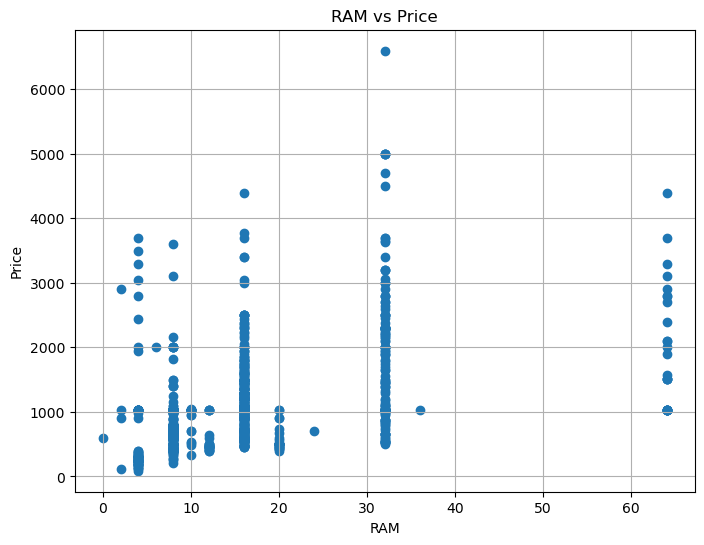

In [114]:
plt.figure(figsize=(8,6))
plt.grid(True)
plt.scatter(df['Ram'],df['Price'])
plt.xlabel('RAM')
plt.ylabel('Price')
plt.title('RAM vs Price')
plt.show()
